In [1]:
!pip install osmnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.4 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
city = "Newcastle upon Tyne, UK"

# Load unsimplified drive network
G = ox.graph_from_place(city, network_type='drive', simplify=False)
nodes, edges = ox.graph_to_gdfs(G)

# Save CRS info for reference
print(f"CRS: {edges.crs}")
print(f"Total nodes: {len(nodes)}, Total edges: {len(edges)}")

CRS: epsg:4326
Total nodes: 40045, Total edges: 76121


In [4]:
edges.info()
edges.head()


<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 76121 entries, (np.int64(6565636), np.int64(7597931210), np.int64(0)) to (np.int64(13105277207), np.int64(13104646085), np.int64(0))
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osmid     76121 non-null  int64   
 1   highway   76121 non-null  object  
 2   lanes     10134 non-null  object  
 3   maxspeed  33989 non-null  object  
 4   oneway    76121 non-null  bool    
 5   ref       9575 non-null   object  
 6   reversed  76121 non-null  bool    
 7   length    76121 non-null  float64 
 8   name      67828 non-null  object  
 9   junction  2237 non-null   object  
 10  access    625 non-null    object  
 11  tunnel    71 non-null     object  
 12  bridge    337 non-null    object  
 13  area      55 non-null     object  
 14  width     30 non-null     object  
 15  geometry  76121 non-null  geometry
dtypes: bool(2), float64(1), geometry(1), int64(1), obje

,,,osmid,highway,lanes,maxspeed,oneway,ref,reversed,length,name,junction,access,tunnel,bridge,area,width,geometry
u,v,key,,,,,,,,,,,,,,,,
6565636,7597931210,0,194663131,trunk,2,60 mph,True,A1,False,87.507520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-1.69356 54.98495, -1.6942 54.98425)"
6565638,7597931213,0,194663131,trunk,2,60 mph,True,A1,False,61.847000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-1.69184 54.98659, -1.69237 54.98612)"
6565639,13800629,0,2953792,trunk,3,60 mph,True,A1,False,155.052646,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-1.68875 54.98896, -1.69024 54.98786)"
6565642,7597931217,0,2953792,trunk,3,60 mph,True,A1,False,230.016185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-1.68446 54.99226, -1.6866 54.9906)"
6565643,7597877084,0,194663137,trunk,2,60 mph,True,A1,False,262.454804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (-1.67957 54.99619, -1.68194 54.99426)"


highway_str
residential       49822
tertiary           8348
unclassified       6587
primary            5109
secondary          3717
trunk              1007
trunk_link          647
living_street       250
motorway_link       180
primary_link        173
motorway            123
secondary_link      103
tertiary_link        55
Name: count, dtype: int64


<Axes: title={'center': 'OSM Road Type Distribution'}, xlabel='highway_str'>

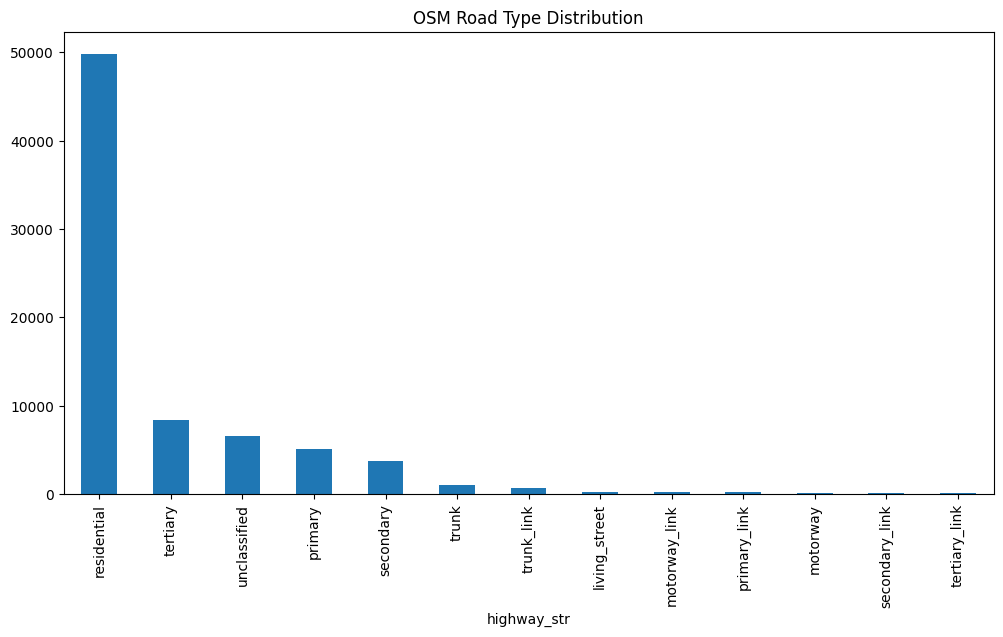

In [5]:
# convert to string for counting
edges['highway_str'] = edges['highway'].apply(lambda x: x[0] if isinstance(x, list) else x)

road_type_counts = edges['highway_str'].value_counts()
print(road_type_counts)
road_type_counts.plot(kind='bar', figsize=(12,6), title="OSM Road Type Distribution")


highway_str
residential       1290.738617
tertiary           219.725737
unclassified       133.783090
primary            111.195581
secondary           86.618854
trunk               56.532350
trunk_link          23.796132
living_street        4.520095
motorway_link        3.892932
motorway             3.863890
primary_link         1.589365
secondary_link       0.813650
tertiary_link        0.550259
Name: length_km, dtype: float64


<Axes: title={'center': 'Total Road Length by Type (km)'}, xlabel='highway_str'>

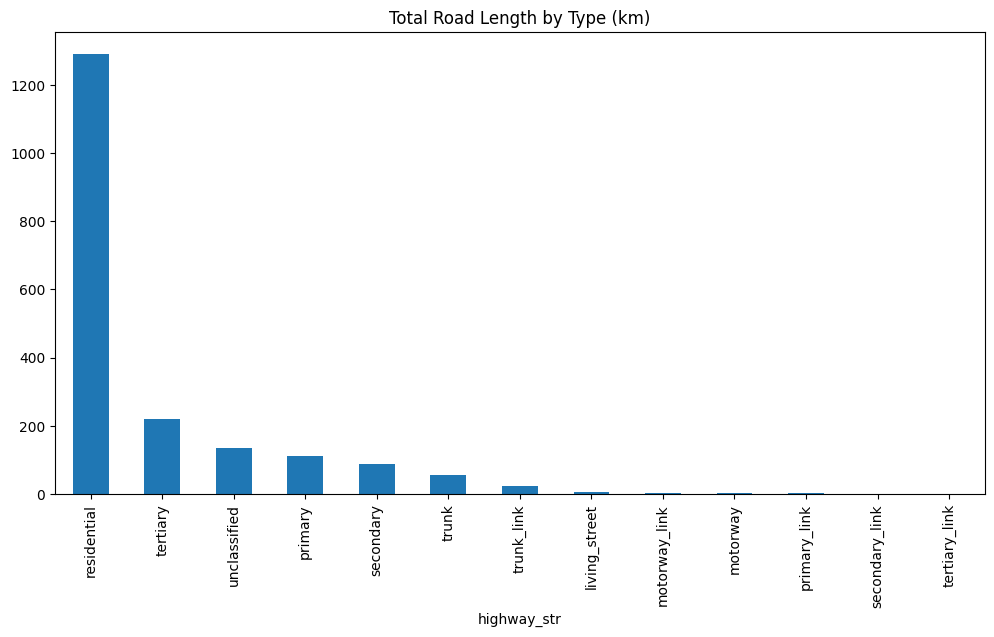

In [6]:
edges['length_km'] = edges['length'] / 1000
length_by_type = edges.groupby('highway_str')['length_km'].sum().sort_values(ascending=False)
print(length_by_type)
length_by_type.plot(kind='bar', figsize=(12,6), title="Total Road Length by Type (km)")


In [7]:
countpoints = pd.read_csv("/content/dft_countpoints_local_authority_id_172.csv")  #  file path
aadt = pd.read_csv("/content/dft_aadf_local_authority_id_172.csv")  #  file path

print("Countpoints Shape:", countpoints.shape)
print("AADT Shape:", aadt.shape)

print("\nCountpoints Columns:")
print(countpoints.columns)

print("\nAADT Columns:")
print(aadt.columns)

# Quick look at distributions
print("\nRoad Type Distribution (Countpoints):")
print(countpoints["road_type"].value_counts())

# Merge AADT with countpoints on 'count_point_id'
aadt_full = pd.merge(aadt, countpoints, on="count_point_id", suffixes=("_aadt", "_cp"))
print("Merged Data Shape:", aadt_full.shape)

Countpoints Shape: (211, 15)
AADT Shape: (2587, 31)

Countpoints Columns:
Index(['count_point_id', 'region_id', 'region_name', 'local_authority_id',
       'local_authority_name', 'road_name', 'road_type',
       'start_junction_road_name', 'end_junction_road_name', 'easting',
       'northing', 'latitude', 'longitude', 'link_length_km',
       'link_length_miles'],
      dtype='object')

AADT Columns:
Index(['count_point_id', 'year', 'region_id', 'region_name',
       'local_authority_id', 'local_authority_name', 'road_name', 'road_type',
       'start_junction_road_name', 'end_junction_road_name', 'easting',
       'northing', 'latitude', 'longitude', 'link_length_km',
       'link_length_miles', 'estimation_method', 'estimation_method_detailed',
       'pedal_cycles', 'two_wheeled_motor_vehicles', 'cars_and_taxis',
       'buses_and_coaches', 'lgvs', 'hgvs_2_rigid_axle', 'hgvs_3_rigid_axle',
       'hgvs_4_or_more_rigid_axle', 'hgvs_3_or_4_articulated_axle',
       'hgvs_5_articulat

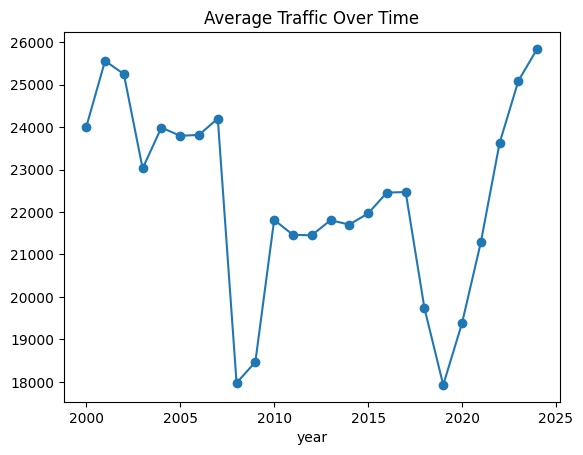

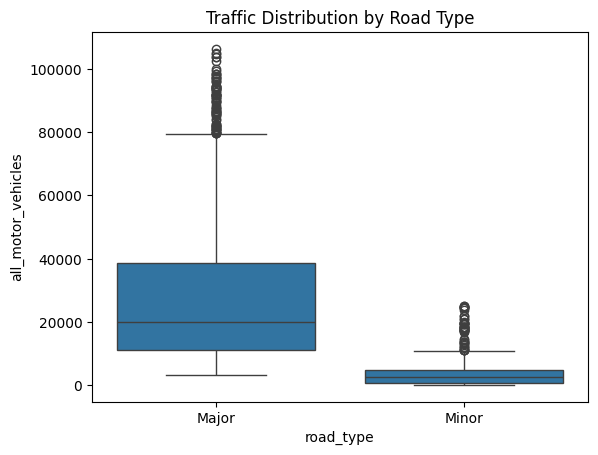

In [8]:
traffic_trend = aadt.groupby("year")["all_motor_vehicles"].mean()
traffic_trend.plot(kind="line", marker="o", title="Average Traffic Over Time")
plt.show()

# Traffic distribution for minor vs major
sns.boxplot(data=aadt, x="road_type", y="all_motor_vehicles")
plt.title("Traffic Distribution by Road Type")
plt.show()

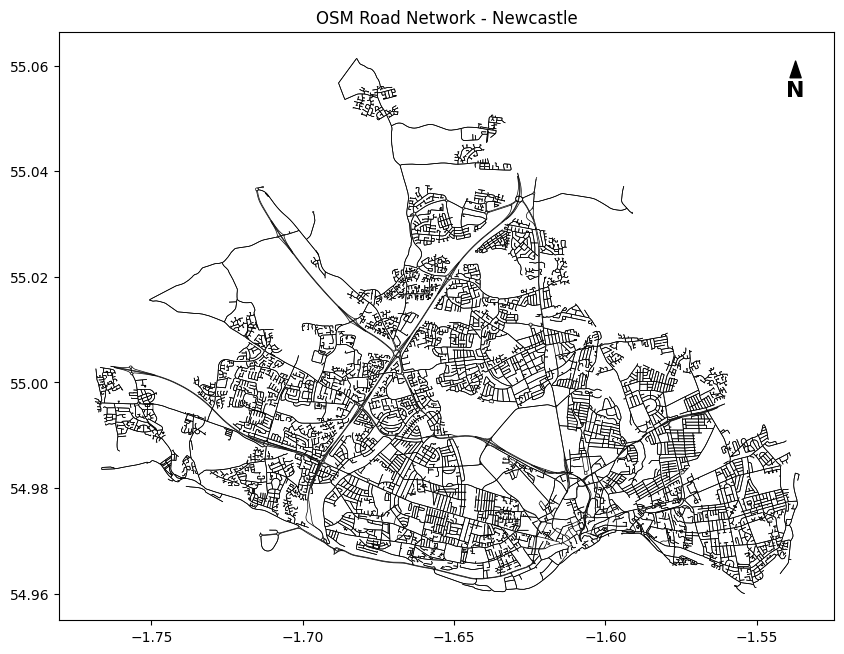

In [9]:
# Get the graph
place_name = "Newcastle upon Tyne, UK"
graph = ox.graph_from_place(place_name, network_type="drive")

# Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(graph)

# Plot road network
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, linewidth=0.5, color="black")
ax.set_title("OSM Road Network - Newcastle")

# Adding direction
x, y = 0.95, 0.95  # position in axes coordinates (top-right)
ax.annotate('N', xy=(x, y), xytext=(x, y-0.05),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            arrowprops=dict(facecolor='black', width=2, headwidth=8))

plt.show()


In [10]:
# 5. Preprocessing
# Keep only major + minor types
target_types = ["primary", "secondary", "tertiary", "unclassified",
                "residential", "trunk", "motorway", "service"]
edges = edges[edges["highway"].apply(lambda x: any(ht in target_types for ht in ([x] if isinstance(x, str) else x)))]

# Drop rows with missing geometry
edges = edges.dropna(subset=["geometry"])

In [11]:
# all columns from AADT
aadt_core = aadt.copy()

# only ID + coordinates from countpoints
countpoints_core = countpoints[[
    "count_point_id", "latitude", "longitude", "road_type", "road_name"
]]

# Merge
aadt_full = pd.merge(aadt_core, countpoints_core, on="count_point_id", how="left")


In [12]:
# After merging and cleaning coordinates
aadt_full = pd.merge(aadt, countpoints, on="count_point_id", suffixes=("_aadt", "_cp"))
aadt_full["latitude"] = aadt_full["latitude_cp"]
aadt_full["longitude"] = aadt_full["longitude_cp"]
aadt_full = aadt_full.drop(columns=["latitude_aadt", "longitude_aadt", "latitude_cp", "longitude_cp"], errors="ignore")

# Create GeoDataFrame
gdf_aadt = gpd.GeoDataFrame(
    aadt_full,
    geometry=gpd.points_from_xy(aadt_full.longitude, aadt_full.latitude),
    crs="EPSG:4326"
)

# Ensure edges are in same starting CRS
edges = edges.to_crs(epsg=4326)

# Project both to British National Grid for accurate nearest search
gdf_aadt_proj = gdf_aadt.to_crs(epsg=27700)
edges_proj = edges.to_crs(epsg=27700)

# Spatial join in projected coordinates
joined_proj = gpd.sjoin_nearest(gdf_aadt_proj, edges_proj, how="left", distance_col="dist_to_road")

# Convert back to EPSG:4326 if needed
joined = joined_proj.to_crs(epsg=4326)


In [13]:
# both datasets are in same CRS
edges = edges.to_crs(epsg=4326)

# Spatial join: match each countpoint to nearest road segment
joined = gpd.sjoin_nearest(gdf_aadt, edges, how="left", distance_col="dist_to_road")


/usr/local/lib/python3.12/dist-packages/geopandas/array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [14]:
# 7. Save Integrated Dataset
joined.to_file("integrated_network.geojson", driver="GeoJSON")


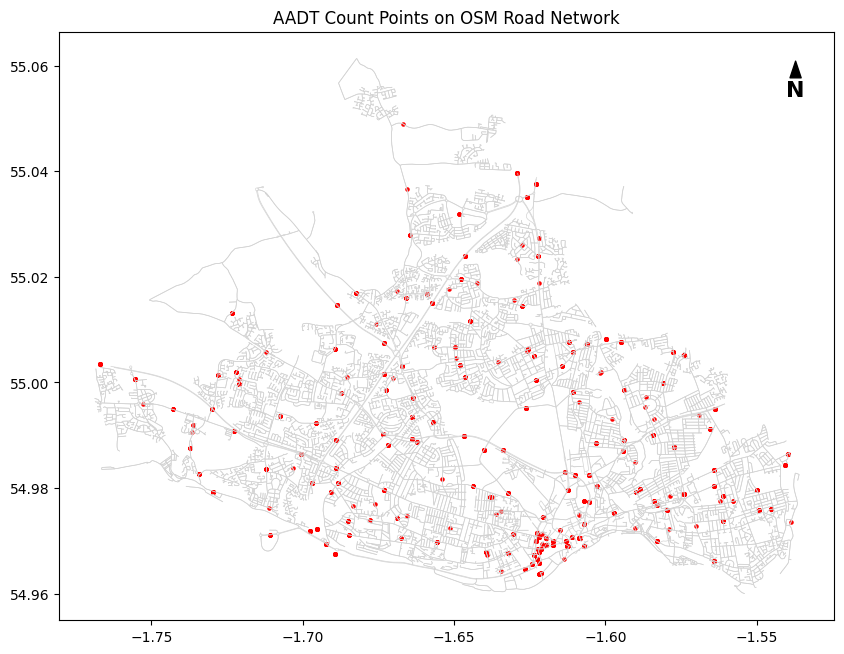

In [15]:
# 8. Visual Check
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="lightgray", linewidth=0.5)
gdf_aadt.plot(ax=ax, color="red", markersize=5)
plt.title("AADT Count Points on OSM Road Network")
x, y = 0.95, 0.95  # axes fraction coordinates
ax.annotate('N', xy=(x, y), xytext=(x, y-0.05),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            arrowprops=dict(facecolor='black', width=2, headwidth=8))
plt.show()

count    3326.000000
mean        9.010142
std        21.981224
min         0.010360
25%         1.049062
50%         2.714524
75%         6.115917
max       163.845140
Name: dist_meters, dtype: float64
Number of points > 50 m from nearest road: 162


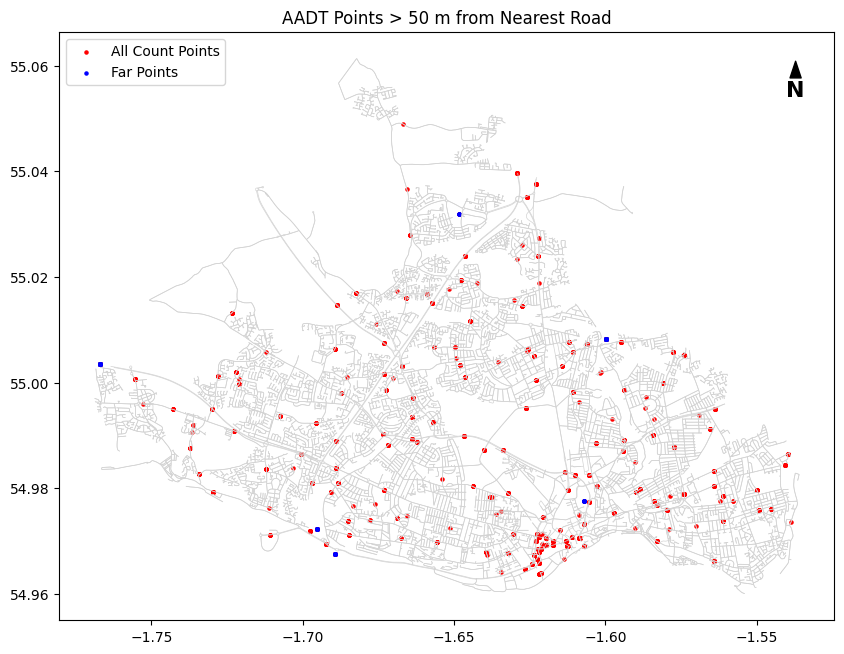

In [20]:
# Step 9: Quantitative validation
# Convert to projected CRS for accurate distance in meters
gdf_aadt_m = gdf_aadt.to_crs(epsg=27700)  # British National Grid
edges_m = edges.to_crs(epsg=27700)

# Spatial join in meters
joined_m = gpd.sjoin_nearest(gdf_aadt_m, edges_m, how="left", distance_col="dist_meters")

# Back to WGS84 for saving/visualization
joined_m = joined_m.to_crs(epsg=4326)

print(joined_m["dist_meters"].describe())

# Flag far points
threshold = 50  # meters
far_points = joined_m[joined_m["dist_meters"] > threshold]
print(f"Number of points > {threshold} m from nearest road: {len(far_points)}")


fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="lightgray", linewidth=0.5)
gdf_aadt.plot(ax=ax, color="red", markersize=5, label="All Count Points")
far_points.plot(ax=ax, color="blue", markersize=5, label="Far Points")
plt.legend()
plt.title(f"AADT Points > {threshold} m from Nearest Road")
# Add north arrow (top-right corner)
x, y = 0.95, 0.95  # axes fraction coordinates
ax.annotate('N', xy=(x, y), xytext=(x, y-0.05),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16, fontweight='bold',
            arrowprops=dict(facecolor='black', width=2, headwidth=8))
plt.show()
